In [92]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1500

# توليد الأعمار بتوزيع واقعي (أكبر عدد في 20-60)
ages = np.random.normal(loc=50, scale=18, size=n).astype(int)
ages = np.clip(ages, 0, 90)

# Heart Rate (عادة 60-100، والقليل خارج)
heart_rates = np.random.normal(loc=85, scale=15, size=n).astype(int)
heart_rates = np.clip(heart_rates, 40, 160)

# Blood Pressure (Systolic)
bp = np.random.normal(loc=130, scale=20, size=n).astype(int)
bp = np.clip(bp, 80, 200)

# Temperature (37±1 طبيعية)
temps = np.random.normal(loc=37, scale=1, size=n).round(1)
temps = np.clip(temps, 35, 41)

# Glucose (ـ عادي / ما قبل سكري / عالي)
glucose = np.random.normal(loc=120, scale=40, size=n).astype(int)
glucose = np.clip(glucose, 60, 350)

# Gender + Diabetes
genders = np.random.choice(['Male','Female'], n)
diabetes = np.random.choice(['Yes','No'], n, p=[0.15, 0.85])  # سكر أقل انتشار

# Symptoms مع احتمال واقعي
symptoms = np.random.choice(
    ['Chest Pain','Breathing Difficulty','Fever','Injury','Other'],
    n,
    p=[0.15, 0.10, 0.30, 0.20, 0.25]
)

df = pd.DataFrame({
    'Age': ages,
    'Gender': genders,
    'HeartRate': heart_rates,
    'BloodPressure': bp,
    'Temperature': temps,
    'Glucose': glucose,
    'Diabetes': diabetes,
    'Symptoms': symptoms
})

# قواعد أكثر واقعية لتحديد المخاطر
def assign_risk(row):
    score = 0

    # العمر
    if row['Age'] >= 65:
        score += 2
    elif row['Age'] >= 45:
        score += 1

    # Heart Rate
    if row['HeartRate'] > 120:
        score += 2
    elif row['HeartRate'] > 100:
        score += 1

    # Blood Pressure
    if row['BloodPressure'] > 160:
        score += 2
    elif row['BloodPressure'] > 140:
        score += 1

    # Glucose
    if row['Glucose'] > 200:
        score += 2
    elif row['Glucose'] > 150:
        score += 1

    # Symptoms
    if row['Symptoms'] in ['Chest Pain','Breathing Difficulty']:
        score += 2
    elif row['Symptoms'] == 'Fever':
        score += 1

    # Diabetes
    if row['Diabetes'] == 'Yes':
        score += 1

    # Risk assignment
    if score >= 5:
        return 'High'
    elif score >= 3:
        return 'Medium'
    else:
        return 'Low'

df['RiskLevel'] = df.apply(assign_risk, axis=1)

df.to_csv('emergency_data.csv', index=False)

In [93]:
df['RiskLevel'].value_counts(), df.head()

(RiskLevel
 Low       792
 Medium    549
 High      159
 Name: count, dtype: int64,
    Age  Gender  HeartRate  BloodPressure  Temperature  Glucose Diabetes  \
 0   58    Male         96             91         36.0       75       No   
 1   47  Female         76            112         35.6       94      Yes   
 2   61    Male         72            121         35.4       82       No   
 3   77  Female         84            167         37.4       98       No   
 4   45    Male         82            141         36.8      111      Yes   
 
                Symptoms RiskLevel  
 0  Breathing Difficulty    Medium  
 1            Chest Pain    Medium  
 2                 Fever       Low  
 3                 Other    Medium  
 4                Injury    Medium  )

#EDA + تنظيف البيانات

In [94]:
# نظرة عامة
print(df.info())
print(df.describe())
print(df['RiskLevel'].value_counts())

# تحويل الأعمدة الفئوية إلى أرقام
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Diabetes'] = df['Diabetes'].map({'Yes':1,'No':0})
df = pd.get_dummies(df, columns=['Symptoms'], drop_first=False)

# التحقق من القيم المفقودة
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            1500 non-null   int64  
 1   Gender         1500 non-null   object 
 2   HeartRate      1500 non-null   int64  
 3   BloodPressure  1500 non-null   int64  
 4   Temperature    1500 non-null   float64
 5   Glucose        1500 non-null   int64  
 6   Diabetes       1500 non-null   object 
 7   Symptoms       1500 non-null   object 
 8   RiskLevel      1500 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 105.6+ KB
None
               Age    HeartRate  BloodPressure  Temperature      Glucose
count  1500.000000  1500.000000    1500.000000  1500.000000  1500.000000
mean     50.313333    84.734000     128.667333    36.977533   120.141333
std      17.590872    14.757838      20.195393     0.978738    38.851834
min       0.000000    40.000000      80.000000   

#تقسيم البيانات + Scaling + تدريب النموذج

In [95]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Features & Target
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# نموذج Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# تنبؤات
y_pred = model.predict(X_test_scaled)

#تقييم النموذج

              precision    recall  f1-score   support

        High       0.88      0.47      0.61        32
         Low       0.92      0.99      0.96       158
      Medium       0.84      0.86      0.85       110

    accuracy                           0.89       300
   macro avg       0.88      0.78      0.81       300
weighted avg       0.89      0.89      0.88       300



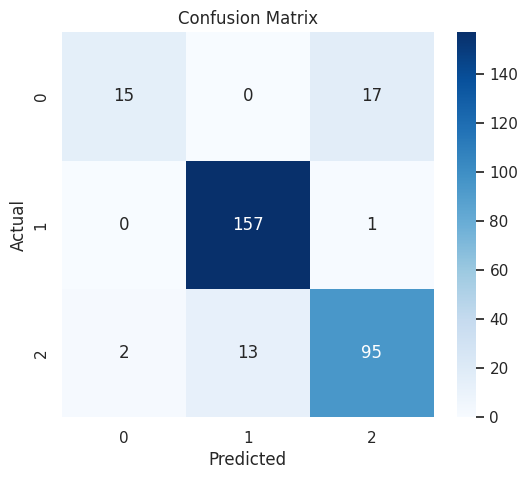

                          Feature  Importance
0                             Age    0.216721
3                   BloodPressure    0.167057
5                         Glucose    0.144816
2                       HeartRate    0.113873
4                     Temperature    0.066645
8             Symptoms_Chest Pain    0.066339
6                        Diabetes    0.047529
7   Symptoms_Breathing Difficulty    0.047438
11                 Symptoms_Other    0.045746
10                Symptoms_Injury    0.033009
9                  Symptoms_Fever    0.032475
1                          Gender    0.018352


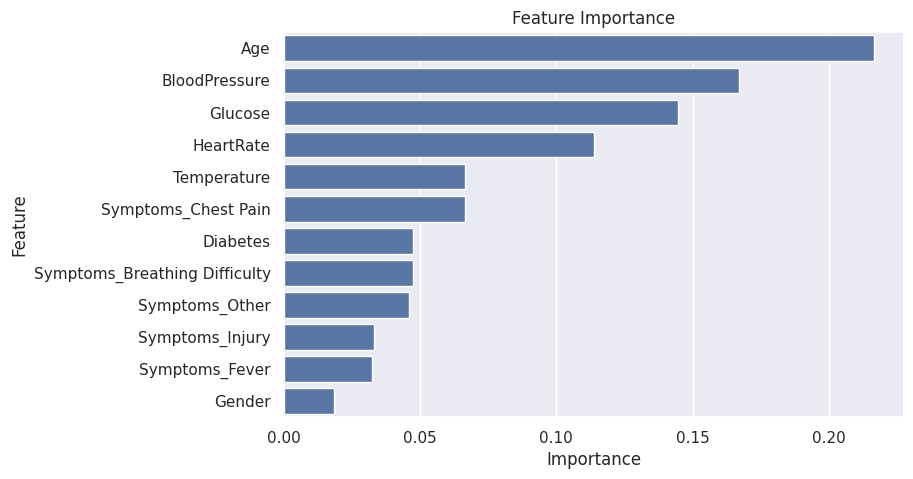

In [96]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature Importance
importances = model.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print(feat_imp)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Feature Importance')
plt.show()

# واجهة تفاعلية تظهر للمسعف

In [99]:
from ipywidgets import interact, widgets
from IPython.display import display

def predict_risk(Age, Gender, HeartRate, BloodPressure, Temperature, Glucose, Diabetes, Symptoms):
    data = pd.DataFrame({
        'Age':[Age],
        'Gender':[1 if Gender=='Male' else 0],
        'HeartRate':[HeartRate],
        'BloodPressure':[BloodPressure],
        'Temperature':[Temperature],
        'Glucose':[Glucose],
        'Diabetes':[1 if Diabetes=='Yes' else 0],
        'Symptoms_Breathing Difficulty':[1 if 'Breathing Difficulty' in Symptoms else 0],
        'Symptoms_Chest Pain':[1 if 'Chest Pain' in Symptoms else 0],
        'Symptoms_Fever':[1 if 'Fever' in Symptoms else 0],
        'Symptoms_Injury':[1 if 'Injury' in Symptoms else 0],
        'Symptoms_Other':[1 if 'Symptoms_Other' in Symptoms else 0]
    })
    data_scaled = scaler.transform(data)
    risk = model.predict(data_scaled)[0]
    print(f"Predicted Risk Level: {risk}")

# Widgets
interact(predict_risk,
         Age=widgets.IntSlider(min=0,max=90,value=50),
         Gender=widgets.Dropdown(options=['Male','Female'],value='Male'),
         HeartRate=widgets.IntSlider(min=40,max=160,value=85),
         BloodPressure=widgets.IntSlider(min=80,max=200,value=130),
         Temperature=widgets.FloatSlider(min=35,max=41,value=37,step=0.1),
         Glucose=widgets.IntSlider(min=60,max=350,value=120),
         Diabetes=widgets.Dropdown(options=['Yes','No'],value='No'),
         Symptoms=widgets.SelectMultiple(options=['Chest Pain','Breathing Difficulty','Fever','Injury','Other'],value=['Fever']))

interactive(children=(IntSlider(value=50, description='Age', max=90), Dropdown(description='Gender', options=(…

<function __main__.predict_risk(Age, Gender, HeartRate, BloodPressure, Temperature, Glucose, Diabetes, Symptoms)>